# Visualización de nódulos procesados

Carga los parches CT y máscaras generados por `process_all_masks.py` y permite explorarlos visualmente.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [11]:
# Cargar metadata
output_dir = "output"
meta = pd.read_csv(os.path.join(output_dir, "metadata.csv"))
print(f"Total nódulos: {len(meta)}")
meta.head(10)

Total nódulos: 2663


,patient_id,nodule_idx,num_annotations,mask_shape,bbox_x,bbox_y,bbox_z,subtlety,internalStructure,calcification,sphericity,margin,lobulation,spiculation,texture,malignancy
0,LIDC-IDRI-0078,0,4,"(34, 44, 6)",294-328,306-350,23-29,4.50,1.0,6.00,4.00,3.25,2.25,2.25,4.75,3.75
1,LIDC-IDRI-0078,1,4,"(40, 27, 6)",146-186,349-376,44-50,4.75,1.0,6.00,4.00,2.75,3.00,2.25,4.50,3.75
2,LIDC-IDRI-0078,2,1,"(8, 7, 2)",345-353,333-340,47-49,4.00,1.0,5.00,5.00,5.00,1.00,1.00,5.00,1.00
3,LIDC-IDRI-0078,3,4,"(50, 40, 8)",221-271,324-364,64-72,5.00,1.0,5.00,3.75,3.25,3.25,2.75,4.75,4.25
4,LIDC-IDRI-0069,0,4,"(26, 19, 9)",359-385,158-177,36-45,2.50,1.0,6.00,4.50,4.25,4.00,4.00,4.75,3.25
5,LIDC-IDRI-0069,1,1,"(6, 7, 1)",337-343,223-230,52-53,2.00,1.0,6.00,4.00,4.00,5.00,5.00,5.00,2.00
6,LIDC-IDRI-0069,2,4,"(29, 43, 11)",359-388,96-139,79-90,4.75,1.0,6.00,3.75,3.50,4.25,3.50,4.75,3.50
7,LIDC-IDRI-0079,0,4,"(27, 22, 5)",372-399,350-372,67-72,4.50,1.0,5.75,3.75,3.75,2.25,1.50,4.75,2.50
8,LIDC-IDRI-0101,0,2,"(21, 8, 2)",301-322,45-53,69-71,3.50,1.0,6.00,2.50,3.00,1.00,1.00,4.50,2.00
9,LIDC-IDRI-0110,0,3,"(17, 17, 4)",360-377,189-206,44-48,4.00,1.0,6.00,4.67,2.33,2.67,2.00,3.33,3.33


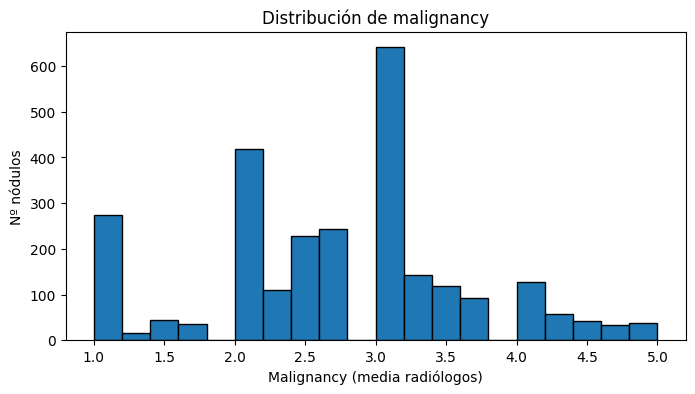

In [12]:
# Distribución de malignancy
plt.figure(figsize=(8, 4))
plt.hist(meta["malignancy"], bins=20, edgecolor="black")
plt.xlabel("Malignancy (media radiólogos)")
plt.ylabel("Nº nódulos")
plt.title("Distribución de malignancy")
plt.show()

In [13]:
# Elegir un nódulo por índice de la tabla
nodule_row = 0  # <-- cambia este valor para explorar otros nódulos

row = meta.iloc[nodule_row]
fname = f"{row.patient_id}_nod{int(row.nodule_idx)}.npy"

ct = np.load(os.path.join(output_dir, "CT", fname))
mask = np.load(os.path.join(output_dir, "masks", fname))

print(f"Paciente: {row.patient_id}")
print(f"Nódulo: {int(row.nodule_idx)}")
print(f"Shape: {ct.shape}")
print(f"Anotaciones: {int(row.num_annotations)}")
print(f"Malignancy: {row.malignancy}")

Paciente: LIDC-IDRI-0078
Nódulo: 0
Shape: (34, 44, 6)
Anotaciones: 4
Malignancy: 3.75


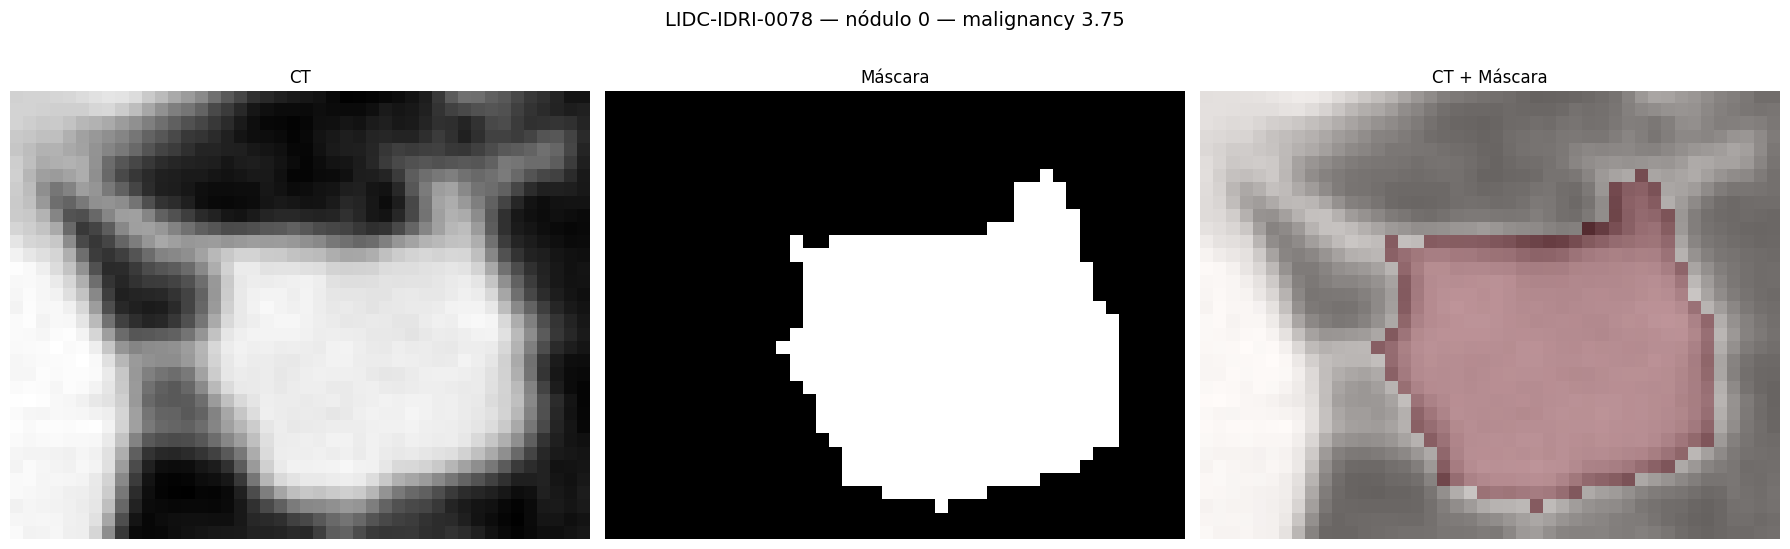

In [14]:
# Visualizar el slice central: CT, máscara, y overlay
slice_idx = ct.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ct[:, :, slice_idx], cmap="gray")
axes[0].set_title("CT")
axes[0].axis("off")

axes[1].imshow(mask[:, :, slice_idx], cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(ct[:, :, slice_idx], cmap="gray")
axes[2].imshow(mask[:, :, slice_idx], alpha=0.4, cmap="Reds")
axes[2].set_title("CT + Máscara")
axes[2].axis("off")

plt.suptitle(f"{row.patient_id} — nódulo {int(row.nodule_idx)} — malignancy {row.malignancy}", fontsize=14)
plt.tight_layout()
plt.show()

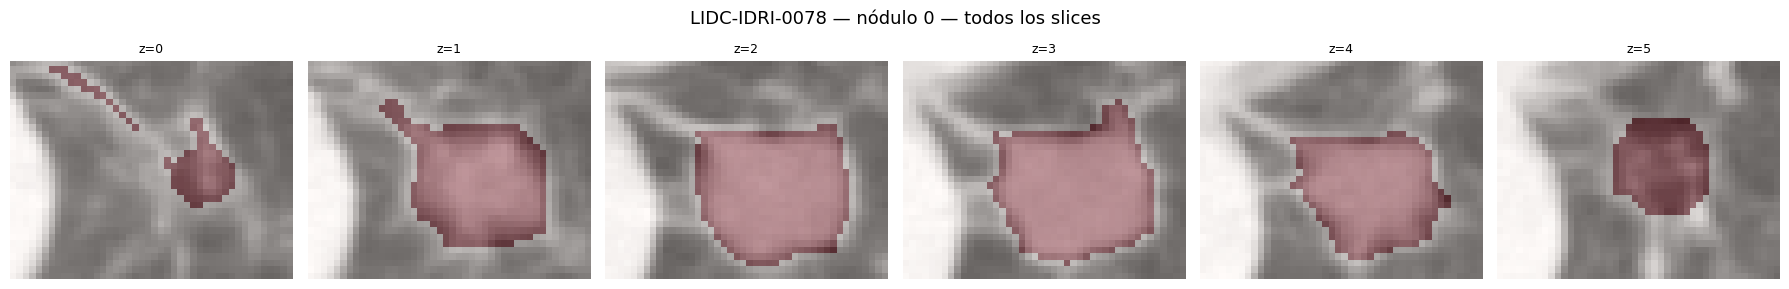

In [15]:
# Visualizar todos los slices del nódulo
n_slices = ct.shape[2]
cols = min(n_slices, 6)
rows_grid = (n_slices + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(3 * cols, 3 * rows_grid))
axes = np.atleast_2d(axes)

for i in range(rows_grid * cols):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    if i < n_slices:
        ax.imshow(ct[:, :, i], cmap="gray")
        ax.imshow(mask[:, :, i], alpha=0.4, cmap="Reds")
        ax.set_title(f"z={i}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"{row.patient_id} — nódulo {int(row.nodule_idx)} — todos los slices", fontsize=13)
plt.tight_layout()
plt.show()

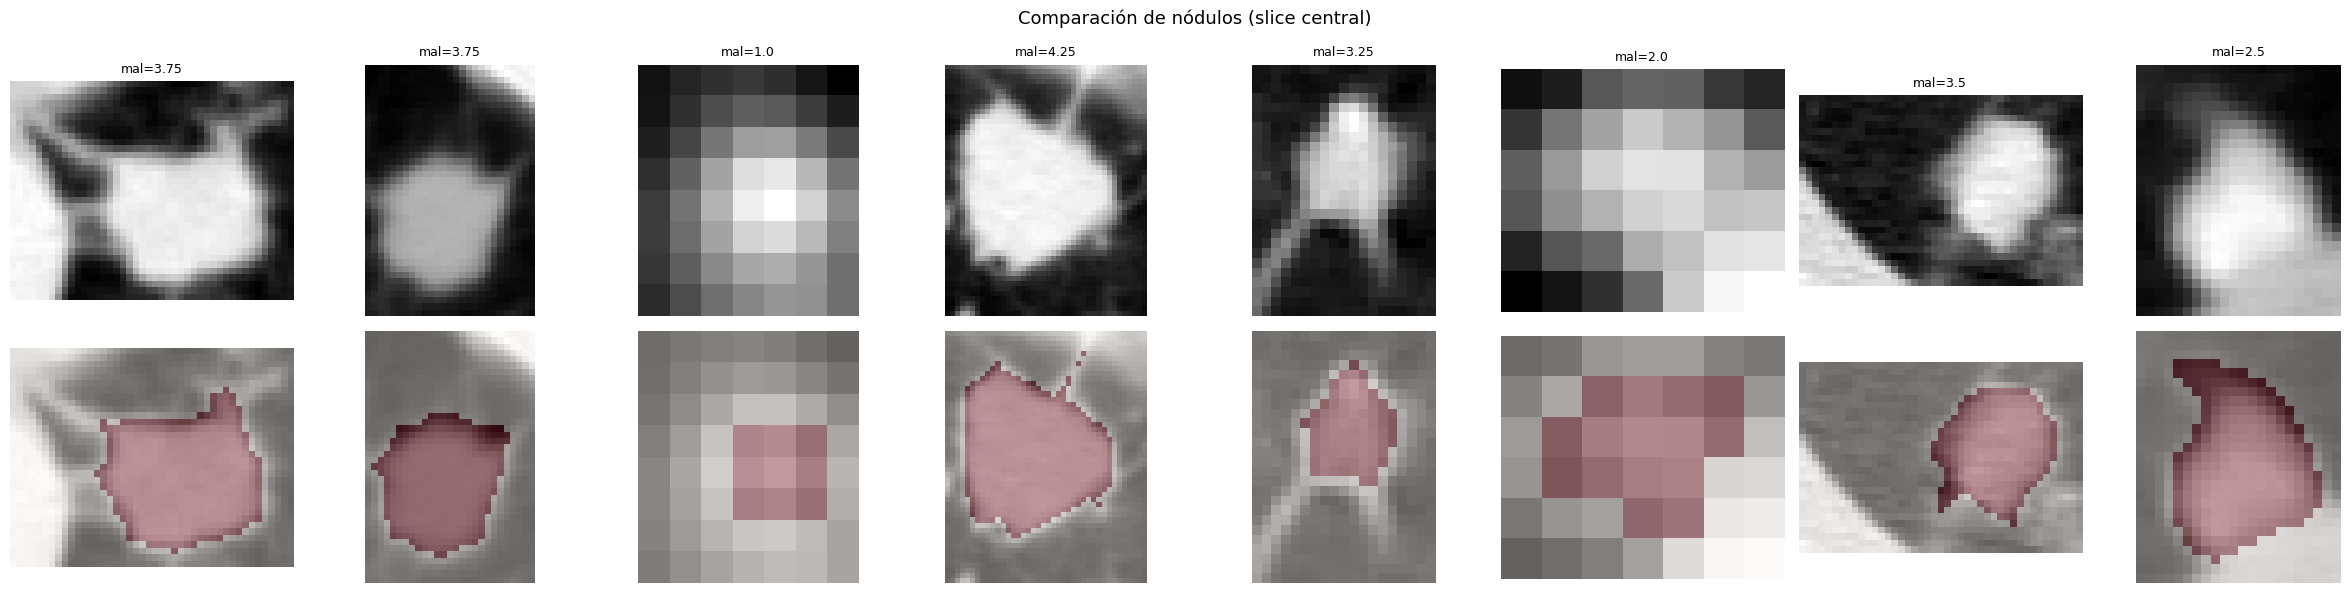

In [16]:
# Comparar varios nódulos lado a lado (slice central de cada uno)
n_show = min(8, len(meta))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))

for i in range(n_show):
    r = meta.iloc[i]
    f = f"{r.patient_id}_nod{int(r.nodule_idx)}.npy"
    ct_i = np.load(os.path.join(output_dir, "CT", f))
    mask_i = np.load(os.path.join(output_dir, "masks", f))
    z = ct_i.shape[2] // 2

    axes[0, i].imshow(ct_i[:, :, z], cmap="gray")
    axes[0, i].set_title(f"mal={r.malignancy}", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(ct_i[:, :, z], cmap="gray")
    axes[1, i].imshow(mask_i[:, :, z], alpha=0.4, cmap="Reds")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("CT", fontsize=11)
axes[1, 0].set_ylabel("CT + Máscara", fontsize=11)
plt.suptitle("Comparación de nódulos (slice central)", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# Resumen de features por nódulo
features = ["subtlety", "sphericity", "margin", "lobulation", "spiculation", "texture", "malignancy"]
meta[features].describe().round(2)

,subtlety,sphericity,margin,lobulation,spiculation,texture,malignancy
count,2663.00,2663.00,2663.00,2663.00,2663.00,2663.00,2663.00
mean,3.66,3.77,3.86,1.63,1.54,4.32,2.70
std,1.08,0.78,1.08,0.84,0.85,1.15,0.92
min,1.00,1.00,1.00,1.00,1.00,1.00,1.00
25%,3.00,3.00,3.25,1.00,1.00,4.00,2.00
50%,4.00,4.00,4.00,1.33,1.00,5.00,2.75
75%,4.50,4.33,4.75,2.00,1.75,5.00,3.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00
